# Predicting Emergency Department Length of Stay

## What is this notebook?

This notebook builds a machine learning model that predicts **how long a patient will stay in the Emergency Department (ED)**, using the information available at the moment of triage, **including** the triage acuity.

The model is trained on records from 80,000 ED visits and validated on an additional 20,000 unseen visits.

---

## Why does predicting length of stay matter?

Crowding and boarding are among the most significant operational challenges in emergency medicine. A patient who will ultimately spend 8 hours in the ED uses fundamentally different resources than one who will be discharged in 90 minutes — but at triage, both may look comparable to nursing staff.

Knowing the *likely* length of stay early enables:

- **Bed allocation** — reserving a monitored bay or resus space before demand peaks
- **Staffing adjustments** — anticipating workload 2–4 hours ahead, not after queues form
- **Fast-track routing** — directing predicted short-stay patients to appropriate care pathways immediately
- **Admission planning** — alerting ward teams earlier when a patient is likely to need a bed
- **Family communication** — giving patients realistic waiting time expectations at registration

---

## Two prediction approaches in this notebook

| Approach | Output | Best used for |
|---|---|---|
| **Regression** | Exact hours (e.g., "predicted stay: 4.2 h") | Detailed resource scheduling, displaying on dashboards |
| **Binary classification** | Yes/No flag for stays > 4.5 h | Simple bed alerts, fast-track routing decisions |

Both models use the same input features and the same training data. The classification model is derived from the same prediction engine but is calibrated to maximise sensitivity for long stays — meaning it errs on the side of flagging rather than missing.

---

## What information does the model use?

All inputs are **triage-time data only** — the model excludes the disposition outcome. Inputs include:

- **Vital signs** at triage: heart rate, blood pressure, SpO₂, temperature, respiratory rate, GCS
- **Chief complaint** (free text, as documented by the nurse)
- **Demographics**: age, sex, language
- **Medical history**: comorbidities (hypertension, diabetes, COPD, etc.), current medications
- **Arrival context**: mode (ambulance vs walk-in), shift (day/night), day of week, season
- **Prior utilisation**: number of ED visits and hospital admissions in the preceding 12 months
- **Triage nurse assessment**: triage acuity score, pain score, pain location, mental status

---

## How the notebook is structured

1. **Feature engineering** — deriving clinically-meaningful composite signals from raw triage variables (e.g., shock index, qSOFA, organ-system comorbidity burden), replicating the approach used for the triage acuity prediction.
2. **Data preparation** — splitting into training and validation sets, encoding categorical variables, handling missing values
3. **Model training** — fitting both the regression (hours) and classification (long/short) models
4. **Validation** — measuring accuracy on patients the model has never seen
5. **Error analysis** — understanding where and why predictions fail
6. **Explainability (SHAP)** — showing which features drove each individual prediction

In [19]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OrdinalEncoder, OneHotEncoder, TargetEncoder

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## Advanced Clinical Feature Engineering

Raw triage data contains vital signs, demographics, and a chief complaint. But many clinically
important signals are *combinations* of raw values that a nurse mentally integrates at the
bedside. The `engineer_features()` function below derives those compound signals explicitly,
giving the model the same building blocks a clinician uses.

| Feature group | Examples | Why it matters for LOS |
|---|---|---|
| **Hemodynamic ratios** | Modified Shock Index (HR ÷ MAP), pulse-pressure ratio | Detect compensated shock — a normal BP can mask cardiovascular collapse |
| **Sepsis / infection flags** | SIRS-inspired fever + tachycardia + tachypnea | Sepsis workup, IV antibiotics, and ICU transfer extend stays significantly |
| **Comorbidity burden** | CVD burden, neuro burden, psych burden | Multi-organ disease patients require longer workup and observation |
| **Vital sign flags** | SpO₂ < 94%, HR < 50 or > 120 | Abnormal single values that clinical guidelines treat as action thresholds |
| **Validated scores** | qSOFA (≥ 2 = sepsis suspect), NEWS2 tier | Standardised risk tiers used in clinical guidelines and escalation pathways |
| **Frailty / instability** | Age > 75 with ≥ 3 comorbidities, shock + low SpO₂ | Frail elderly patients almost always require admission |
| **Prior utilisation** | > 4 ED visits + admissions in the past 12 months | High utilisers have complex chronic or social needs that prolong stays |
| **Temporal context** | Night shift, weekend | Reduced consultant availability and reduced discharge options extend stays |

**Leakage-free rule:** the comorbidity Q75 threshold is computed on the **training set only**,
then applied identically to the validation set — the model never influences its own evaluation.

In [20]:
def engineer_features(df: pd.DataFrame, comorbidity_q75: float = None) -> pd.DataFrame:
    """
    Derive clinically-motivated composite features from raw triage variables.

    Args:
        df: DataFrame of triage features (X_train or X_val).
        comorbidity_q75: 75th-percentile of num_comorbidities computed on the
            training set only. Pass None only when processing the training set
            itself (it will be computed from df).
    """
    df = df.copy()

    # A. Hemodynamic ratios — detect compensated shock that raw BP misses
    if {"pulse_pressure", "mean_arterial_pressure"}.issubset(df.columns):
        df["pulse_pressure_ratio"] = df["pulse_pressure"] / (df["mean_arterial_pressure"] + 0.1)
    if {"mean_arterial_pressure", "systolic_bp"}.issubset(df.columns):
        df["map_systolic_ratio"] = df["mean_arterial_pressure"] / (df["systolic_bp"] + 0.1)
    if {"heart_rate", "mean_arterial_pressure"}.issubset(df.columns):
        df["MSI"] = df["heart_rate"].fillna(70) / (df["mean_arterial_pressure"].fillna(100) + 0.1)

    # B. Infection / sepsis proxy (SIRS-inspired)
    if {"temperature_c", "heart_rate"}.issubset(df.columns):
        df["infection"] = (
            (df["temperature_c"].fillna(36.5) >= 37.5) |
            (df["temperature_c"].fillna(36.5) < 36.0) |
            (df["heart_rate"].fillna(75) >= 90)
        ).astype(int)
    if {"temperature_c", "heart_rate", "respiratory_rate"}.issubset(df.columns):
        df["sepsis_like"] = (
            ((df["temperature_c"].fillna(36.0) > 38.0) | (df["temperature_c"].fillna(36.0) < 36.0)) &
            ((df["heart_rate"].fillna(0) > 90) | (df["respiratory_rate"].fillna(0) > 20))
        ).astype(int)

    # C. High-risk arrival mode
    if "arrival_mode" in df.columns:
        df["high_risk_arrival"] = df["arrival_mode"].isin(["ambulance", "helicopter"]).astype(int)

    # D. Altered mental status (any non-alert consciousness)
    if "mental_status_triage" in df.columns:
        df["altered_ms"] = df["mental_status_triage"].isin(
            ["confused", "drowsy", "unresponsive", "agitated"]
        ).astype(int)

    # E. Shift / operational temporal flags
    if "shift" in df.columns:
        df["night_shift"] = (df["shift"] == "night").astype(int)
    if "arrival_day" in df.columns:
        df["weekend"] = df["arrival_day"].isin(["Saturday", "Sunday"]).astype(int)

    # F. Comorbidity x vital sign interactions
    if "num_comorbidities" in df.columns:
        _q75 = comorbidity_q75 if comorbidity_q75 is not None else df["num_comorbidities"].quantile(0.75)
        if "heart_rate" in df.columns:
            df["high_comorbidity_tachycardia"] = (
                (df["num_comorbidities"] > _q75) & (df["heart_rate"] > 100)
            ).astype(int)
        if "respiratory_rate" in df.columns:
            df["high_comorbidity_tachypnea"] = (
                (df["num_comorbidities"] > _q75) & (df["respiratory_rate"] > 20)
            ).astype(int)

    # G. Vital sign abnormality flags
    vital_flag_defs = {}
    if "heart_rate" in df.columns:
        vital_flag_defs["heart_rate"] = (50, 120)
    if "respiratory_rate" in df.columns:
        vital_flag_defs["respiratory_rate"] = (12, 20)
    if "spo2" in df.columns:
        vital_flag_defs["spo2"] = (94, 100)
    for vital, (lo, hi) in vital_flag_defs.items():
        df[f"{vital}_abnormal"] = ((df[vital] < lo) | (df[vital] > hi)).astype(int)

    # H. NEWS2 clinical risk tier
    if "news2_score" in df.columns:
        df["news2_risk_level"] = pd.cut(
            df["news2_score"],
            bins=[-np.inf, 4, 6, 7, np.inf],
            labels=["low", "medium", "high", "critical"],
        ).cat.codes

    # I. Age-based clinical flags
    if "age" in df.columns:
        df["is_pediatric"]    = (df["age"] < 16).astype(int)
        df["is_elderly"]      = (df["age"] >= 65).astype(int)
        df["is_very_elderly"] = (df["age"] >= 85).astype(int)

    # J. GCS altered consciousness
    if "gcs_total" in df.columns:
        df["gcs_altered"] = (df["gcs_total"] < 14).astype(int)

    # K. Comorbidity burden by organ system
    def _burden(cols):
        present = [c for c in cols if c in df.columns]
        return df[present].fillna(0).sum(axis=1) if present else pd.Series(0, index=df.index)

    df["cvd_burden"]   = _burden(["hx_hypertension", "hx_heart_failure", "hx_atrial_fibrillation", "hx_coronary_artery_disease"])
    df["resp_burden"]  = _burden(["hx_asthma", "hx_copd"])
    df["neuro_burden"] = _burden(["hx_dementia", "hx_epilepsy", "hx_stroke_prior"])
    df["psych_burden"] = _burden(["hx_depression", "hx_anxiety", "hx_substance_use_disorder"])
    immuno = [c for c in ["hx_hiv", "hx_immunosuppressed", "hx_malignancy"] if c in df.columns]
    if immuno:
        df["immuno_risk"] = (df[immuno].fillna(0).sum(axis=1) > 0).astype(int)
    hx_cols = [c for c in df.columns if c.startswith("hx_")]
    if hx_cols:
        df["worrying_history"] = df[hx_cols].fillna(0).astype(int).sum(axis=1)

    # L. Composite instability / frailty flags
    unstable_parts = []
    if "shock_index" in df.columns:
        unstable_parts.append(df["shock_index"].fillna(0) > 1.0)
    if "spo2" in df.columns:
        unstable_parts.append(df["spo2"].fillna(100) < 92)
    if "gcs_total" in df.columns:
        unstable_parts.append(df["gcs_total"].fillna(15) < 15)
    if unstable_parts:
        df["unstable"] = np.logical_or.reduce([p.values for p in unstable_parts]).astype(int)
    if {"age", "num_comorbidities"}.issubset(df.columns):
        df["frail"] = ((df["age"].fillna(0) > 75) & (df["num_comorbidities"].fillna(0) >= 3)).astype(int)
    if "num_active_medications" in df.columns:
        df["polypharmacy"] = (df["num_active_medications"].fillna(0) >= 5).astype(int)

    # M. Validated clinical scores
    qsofa = pd.Series(0, index=df.index)
    if "respiratory_rate" in df.columns:
        qsofa += (df["respiratory_rate"].fillna(18) >= 22).astype(int)
    if "gcs_total" in df.columns:
        qsofa += (df["gcs_total"].fillna(15) < 15).astype(int)
    if "systolic_bp" in df.columns:
        qsofa += (df["systolic_bp"].fillna(120) <= 100).astype(int)
    df["qSOFA"]          = qsofa
    df["qSOFA_positive"] = (qsofa >= 2).astype(int)
    if {"shock_index", "age"}.issubset(df.columns):
        df["age_shock_index"] = df["shock_index"].fillna(0.6) * df["age"].fillna(40)

    # N. Prior utilization burden
    if {"num_prior_ed_visits_12m", "num_prior_admissions_12m"}.issubset(df.columns):
        df["prior_utilization_burden"] = (
            df["num_prior_ed_visits_12m"].fillna(0) + df["num_prior_admissions_12m"].fillna(0)
        )
        df["high_utilizer"] = (df["prior_utilization_burden"] >= 4).astype(int)

    return df

print("engineer_features() defined — call after the train/val split using comorbidity_q75 from training data.")


engineer_features() defined — call after the train/val split using comorbidity_q75 from training data.


## Loading and Merging the Data

The prediction model draws on four separate data files that are merged into a single patient record:

| File | Contents |
|---|---|
| `train.csv` | Triage variables and observed LOS for 80,000 historical ED visits used to *train* the model |
| `test.csv` | Triage variables for 20,000 held-out visits used to *evaluate* the model (LOS is kept hidden during evaluation) |
| `chief_complaints.csv` | Free-text chief complaint as documented by the triage nurse at registration |
| `patient_history.csv` | Medical history: comorbidities, active medications, prior ED and hospital utilisation |

After merging, the training table has **80,000 rows × 65 columns** and the test table has **20,000 rows × 62 columns** (the three "outcome" columns are absent from the test set as expected).

In [21]:
train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")
chief_complaints_df = pd.read_csv("dataset/chief_complaints.csv")
history_df = pd.read_csv("dataset/patient_history.csv")

# Keep only raw complaint text from chief complaints to avoid leakage through system labels.
if "chief_complaint_system" in chief_complaints_df.columns:
    chief_complaints_df = chief_complaints_df.drop(columns=["chief_complaint_system"] )
if "chief_complaint_system" in train_df.columns:
    train_df = train_df.drop(columns=["chief_complaint_system"] )
if "chief_complaint_system" in test_df.columns:
    test_df = test_df.drop(columns=["chief_complaint_system"] )

patient_info_df = chief_complaints_df.merge(history_df, on="patient_id", how="outer")

train_df = train_df.merge(patient_info_df, on="patient_id", how="left")
test_df = test_df.merge(patient_info_df, on="patient_id", how="left")

print(f"train_df shape: {train_df.shape}")
print(f"test_df shape: {test_df.shape}")
print(f"chief_complaints_df shape: {chief_complaints_df.shape}")
print(f"history_df shape: {history_df.shape}")

train_df shape: (80000, 65)
test_df shape: (20000, 62)
chief_complaints_df shape: (100000, 2)
history_df shape: (100000, 26)


## Defining the Prediction Targets and Input Features

### Regression target: `ed_los_hours`
The continuous outcome. The observed time (in hours) from registration to discharge or admission decision. Summary statistics from the training set:
- **Median: 3.0 h** — half of patients leave within 3 hours
- **Mean: 3.5 h** — pulled upward by complex cases
- **75th percentile: 4.9 h** — one quarter of patients stay longer than this
- **Range: 0 – 17.5 h**

### Binary classification target: `los_long_over_4_5h`
A simpler yes/no version: did the patient stay **more than 4.5 hours**?
- **0 (short stay ≤ 4.5 h):** 71% of visits
- **1 (long stay > 4.5 h):** 29% of visits

The 4.5-hour threshold is explained in detail in the *Understanding the Decision Thresholds* section below.

### Why certain columns are excluded from the model inputs

The variables below are available in the dataset but are **deliberately withheld** from the model:

| Column | Reason for exclusion |
|---|---|
| `patient_id` | An arbitrary identifier — carries no clinical signal |
| `disposition` | Whether the patient was admitted, discharged, or transferred is only known *after* the LOS has occurred; using it would leak the answer into the prediction |
| `ed_los_hours` | The regression target — naturally excluded from inputs |
| `los_long_over_4_5h` | The classification target — naturally excluded from inputs |
| `chief_complaint_system` | System-assigned label not available at the moment of triage |

This constraint — predicting only from information available at triage time — is what makes the model genuinely useful in practice. A model that required a diagnosis to make its prediction would be useless as an early-warning tool.

In [22]:
train_df["los_long_over_4_5h"] = (train_df["ed_los_hours"] > 4.5).astype(int)

print("Binary target created: 1 = LOS > 4.5h, 0 = LOS <= 4.5h")
print(train_df["los_long_over_4_5h"].value_counts().sort_index())
print(train_df["los_long_over_4_5h"].value_counts(normalize=True).sort_index())

Binary target created: 1 = LOS > 4.5h, 0 = LOS <= 4.5h
los_long_over_4_5h
0    56685
1    23315
Name: count, dtype: int64
los_long_over_4_5h
0    0.708562
1    0.291438
Name: proportion, dtype: float64


In [23]:
target_column_regression = "ed_los_hours"
target_column_classification = "los_long_over_4_5h"

leakage_columns = ["patient_id", "disposition", target_column_classification, target_column_regression, "chief_complaint_system"]
feature_columns = [column for column in train_df.columns if column not in leakage_columns]

X = train_df[feature_columns].copy()

y_regression = train_df[target_column_regression].copy()
y_classification = train_df[target_column_classification].copy()

# Raw temporal columns that will be converted into cyclic sin/cos features.
cyclic_time_raw_columns = ["arrival_hour", "arrival_month", "arrival_day"]

text_feature = "chief_complaint_raw"

categorical_features = X.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()
if text_feature in categorical_features:
    categorical_features.remove(text_feature)

numeric_features = [
    column for column in X.columns
    if column not in categorical_features and column != text_feature and column not in cyclic_time_raw_columns
]

print(f"Number of features: {len(feature_columns)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Numeric features: {len(numeric_features)}")
print("Regression target summary:")
print(y_regression.describe())
print("Classification target summary:")
print(y_classification.value_counts().sort_index())

Number of features: 62
Categorical features: 13
Numeric features: 46
Regression target summary:
count    80000.000000
mean         3.498276
std          2.443958
min          0.000000
25%          1.580000
50%          3.000000
75%          4.860000
max         17.510000
Name: ed_los_hours, dtype: float64
Classification target summary:
los_long_over_4_5h
0    56685
1    23315
Name: count, dtype: int64


## Target Distribution: Understanding the Shape of ED Stays

The histogram below shows that most patients have short stays (peak around 1–3 hours), but a long tail extends to 17+ hours. This **right-skewed** distribution is typical of ED length of stay.

**Implications:** The model is trained on the *logarithm* of the stay duration rather than the raw hours. This compresses the long tail and treats each proportional difference equally (e.g., the difference between 1 h and 2 h is treated the same as the difference between 4 h and 8 h). Predictions are then converted back from log scale to hours before being reported.

**Binary classification balance:** Of the 80,000 training visits, 71% are short stays (≤ 4.5 h) and 29% are long stays (> 4.5 h). This imbalance is real and expected — most ED patients are discharged quickly. When evaluating the classification model, we pay particular attention to how well it detects the minority class (long stays), since those are the operationally critical cases.

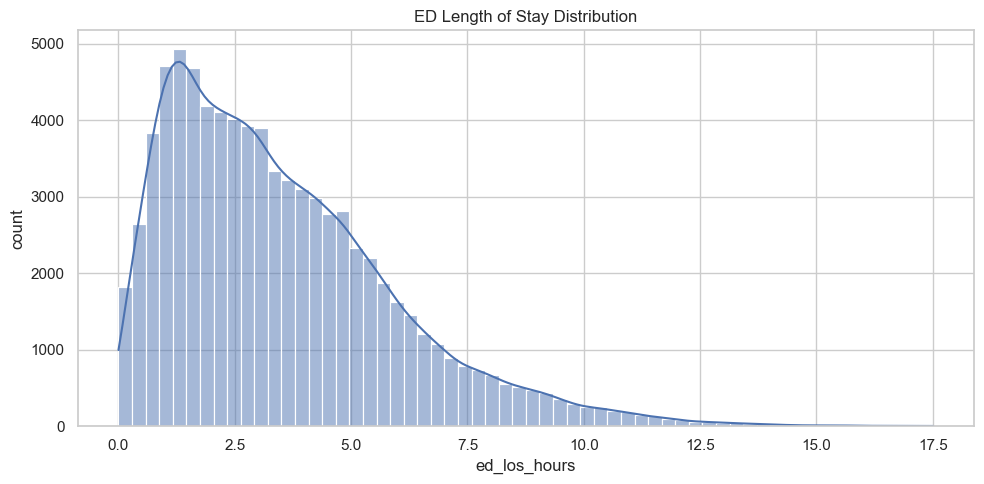

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(y_regression, bins=60, kde=True, ax=ax)
ax.set_title("ED Length of Stay Distribution")
ax.set_xlabel("ed_los_hours")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

/var/folders/mt/mfhlvqrd27lfsxzs4qmmj4000000gn/T/ipykernel_19640/1963869358.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["short stay (<= 4.5h)", "long stay (> 4.5h)"])


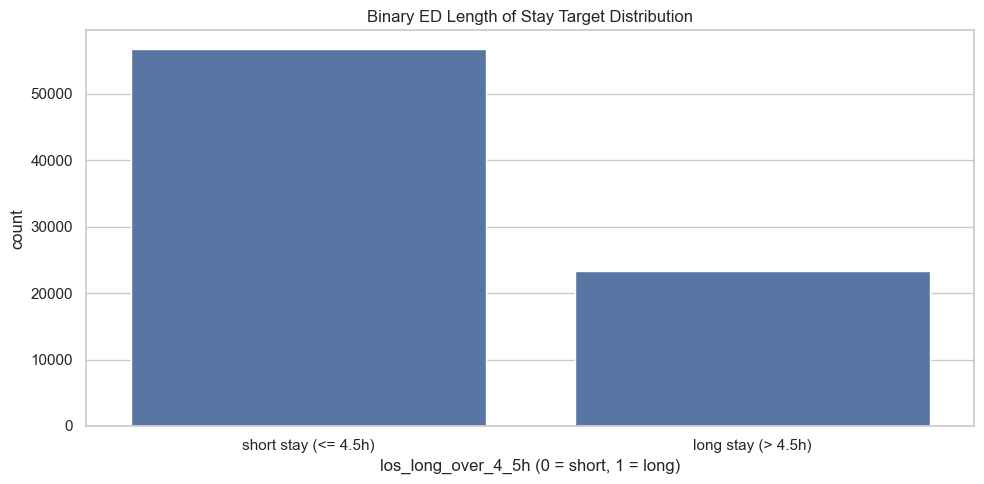

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(x=y_classification, ax=ax)
ax.set_title("Binary ED Length of Stay Target Distribution")
ax.set_xlabel("los_long_over_4_5h (0 = short, 1 = long)")
ax.set_ylabel("count")
ax.set_xticklabels(["short stay (<= 4.5h)", "long stay (> 4.5h)"])
plt.tight_layout()
plt.show()

## Data Preparation Pipeline

Before any data reaches the model, it must be converted into a consistent numerical format. Think of this as the laboratory processing step before analysis — raw samples (patient records) are prepared in a standardised way so the model can work with them reliably.

### What the pipeline does to each type of variable

**Ordered categorical variables** (e.g., age group: *paediatric → young adult → middle-aged → elderly*; mental status: *unresponsive → drowsy → confused → alert*) — converted to an ordered numeric scale that preserves the clinical ranking (elderly > middle-aged, not just "different").

**Unordered categorical variables** (e.g., arrival mode, insurance type, shift, sex) — converted to a separate binary column for each category (e.g., "arrived by ambulance: yes/no"). This prevents the model from inferring false orderings like "ambulance > helicopter mathematically."

**Triage nurse and language** — encoded using a technique that captures the *average LOS associated with each nurse or language group* in the training data. This reflects the real pattern that nurse caseload mix and language barriers correlate with stay duration.

**Time of arrival** — hour, day of week, and month are encoded as circular (sine/cosine) variables. This ensures the model understands that 23:00 and 01:00 are 2 hours apart, not 22 hours apart in a linear scale.

**Missing vital signs** — before replacing missing values with the median, the pipeline creates a separate flag column (e.g., `systolic_bp_missing = 1`) to preserve the clinical information that the measurement was not taken. A missing blood pressure reading is clinically informative — it may indicate the patient was too unstable to measure, or arrived via a pathway without a BP cuff.

**Chief complaint (free text)** — processed using TF-IDF (Term Frequency–Inverse Document Frequency), a standard technique that converts the nurse's typed text into numeric scores reflecting how informative each word is. For example, "necrotising fasciitis" scores highly because it is rare and specific; "pain" scores low because it appears in almost every complaint. The model considers single words, two-word phrases, and three-word phrases (up to 2,000 features in total).

In [26]:
text_feature = 'chief_complaint_raw'

def flatten_text_input(X):
    """Convert incoming column slices to a clean 1D text series for vectorizers."""
    if isinstance(X, pd.DataFrame):
        if text_feature in X.columns:
            s = X[text_feature]
        else:
            s = X.iloc[:, 0]
    elif isinstance(X, pd.Series):
        s = X
    elif isinstance(X, np.ndarray):
        if X.ndim == 2 and X.shape[1] > 0:
            s = pd.Series(X[:, 0])
        else:
            s = pd.Series(np.ravel(X))
    else:
        s = pd.Series(X)

    return s.fillna('missing').astype(str)

In [27]:
acttext_feature = 'chief_complaint_raw'

tfidf_branch = Pipeline([
    ('to_text', FunctionTransformer(flatten_text_input, validate=False)),
    ('tfidf', TfidfVectorizer(
            stop_words="english",
            min_df=3,
            ngram_range=(1, 3),
            max_features=2000
    ))
])

text_pipeline = Pipeline([
    ('tfidf', tfidf_branch),
])

In [28]:
def build_cyclic_time_features(X):
    """Convert hour/month/day into cyclic sin/cos features."""
    if isinstance(X, pd.DataFrame):
        df = X.copy()
    else:
        df = pd.DataFrame(X, columns=["arrival_hour", "arrival_month", "arrival_day"])

    day_to_idx = {
        "monday": 0,
        "tuesday": 1,
        "wednesday": 2,
        "thursday": 3,
        "friday": 4,
        "saturday": 5,
        "sunday": 6,
    }

    hour = pd.to_numeric(df["arrival_hour"], errors="coerce").fillna(0).clip(0, 23)
    month = pd.to_numeric(df["arrival_month"], errors="coerce").fillna(1).clip(1, 12)
    day_idx = (
        df["arrival_day"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(day_to_idx)
        .fillna(0)
        .astype(float)
    )

    hour_sin = np.sin(2 * np.pi * hour / 24.0)
    hour_cos = np.cos(2 * np.pi * hour / 24.0)
    month_sin = np.sin(2 * np.pi * (month - 1) / 12.0)
    month_cos = np.cos(2 * np.pi * (month - 1) / 12.0)
    dow_sin = np.sin(2 * np.pi * day_idx / 7.0)
    dow_cos = np.cos(2 * np.pi * day_idx / 7.0)

    return np.column_stack([hour_sin, hour_cos, month_sin, month_cos, dow_sin, dow_cos])


In [29]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

age_order = ['pediatric', 'young_adult', 'middle_aged', 'elderly']
mental_order = ['unresponsive', 'drowsy', 'confused', 'alert', 'agitated']

preprocessor = ColumnTransformer([
    ("ord", OrdinalEncoder(categories=[age_order, mental_order]), ["age_group", "mental_status_triage"]),
    ("nom", OneHotEncoder(handle_unknown="ignore"), ["arrival_mode", "arrival_season", "insurance_type", "transport_origin", "sex", "shift", "site_id"]),
    ("target", TargetEncoder(), ["triage_nurse_id", "language", "pain_location"]),
    ("time_cyc", FunctionTransformer(build_cyclic_time_features, validate=False), ["arrival_hour", "arrival_month", "arrival_day"]),
    ("num", numeric_pipeline, numeric_features),
    ("chief_complaint_text", text_pipeline, ["chief_complaint_raw"])
], remainder="drop", sparse_threshold=0.0)

regressor = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=10,
    max_iter=1000,
    min_samples_leaf=20,
    random_state=RANDOM_STATE,
    loss="absolute_error",
)
classifier = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=10,
    max_iter=1000,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
)


In [30]:
def split_and_engineer_features(X, y, classification=False):
  # 1. Train/Validation Split
  if classification:
    X_train, X_val, y_train, y_val = train_test_split(
      X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
  else:
    X_train, X_val, y_train, y_val = train_test_split(
      X, y, test_size=0.2, random_state=RANDOM_STATE
    )
  # 2. Pain sentinel fix
  # pain_score = -1 means the nurse did *not* assess pain — clinically different
  # from pain_score = 0 (patient reports no pain). Convert to NaN and flag it.
  for split_df in [X_train, X_val]:
    if "pain_score" in split_df.columns:
        mask = split_df["pain_score"] == -1
        split_df.loc[mask, "pain_score"] = np.nan
        split_df["pain_not_recorded"] = mask.astype(int)
  # 3. MNAR missingness flags
  # "Missing Not At Random": a missing blood pressure is clinically informative
  # (e.g. patient was too unstable to measure, or walk-in with no BP cuff access).
  # Record the missingness as a feature BEFORE imputing.
  mnar_cols = [
     "systolic_bp", "diastolic_bp", "mean_arterial_pressure",
     "pulse_pressure", "shock_index", "respiratory_rate",
  ]
  for col in mnar_cols:
      for split_df in [X_train, X_val]:
          if col in split_df.columns:
              split_df[f"{col}_missing"] = split_df[col].isna().astype(int)

  # 4. Feature engineering
  # comorbidity_q75 is derived from training data ONLY, then applied to val set.
  comorbidity_q75 = (
      X_train["num_comorbidities"].quantile(0.75)
      if "num_comorbidities" in X_train.columns else None
  )
  X_train = engineer_features(X_train, comorbidity_q75=comorbidity_q75)
  X_val   = engineer_features(X_val,   comorbidity_q75=comorbidity_q75)

  new_cols = [c for c in X_train.columns if c not in X.columns]
  print(f"Features: {X.shape[1]} raw → {X_train.shape[1]} after engineering ({len(new_cols)} added)")
  print(f"Added: {new_cols}")
  return X_train, X_val, y_train, y_val, new_cols

In [31]:
X_train_regression, X_val_regression, y_train_regression, y_val_regression, new_cols_regression = split_and_engineer_features(X, y_regression)
X_train_classification, X_val_classification, y_train_classification, y_val_classification, new_cols_classification = split_and_engineer_features(X, y_classification, classification=True)

updated_preprocessor = ColumnTransformer([
    ("ord",     OrdinalEncoder(categories=[age_order, mental_order]),
                ["age_group", "mental_status_triage"]),
    ("nom",     OneHotEncoder(handle_unknown="ignore"),
                ["arrival_mode", "arrival_season", "insurance_type",
                 "transport_origin", "sex", "shift", "site_id"]),
    ("target",  TargetEncoder(),
                ["triage_nurse_id", "language", "pain_location"]),
    ("time_cyc", FunctionTransformer(build_cyclic_time_features, validate=False),
                ["arrival_hour", "arrival_month", "arrival_day"]),
    ("num",     numeric_pipeline, numeric_features + new_cols_regression), # The added columns are the same for both regression and classification pipelines
    ("chief_complaint_text", text_pipeline, ["chief_complaint_raw"]),
], remainder="drop", sparse_threshold=0.0)

regression_model = TransformedTargetRegressor(
    regressor=Pipeline([
        ("preprocess", updated_preprocessor),
        ("regressor", regressor)
    ]),
    func=np.log1p,
    inverse_func=np.expm1
)

classification_model = Pipeline([
    ("preprocess", updated_preprocessor),
    ("classifier", classifier)
])

prediction_threshold = 0.35


Features: 62 raw → 102 after engineering (40 added)
Added: ['pain_not_recorded', 'systolic_bp_missing', 'diastolic_bp_missing', 'mean_arterial_pressure_missing', 'pulse_pressure_missing', 'shock_index_missing', 'respiratory_rate_missing', 'pulse_pressure_ratio', 'map_systolic_ratio', 'MSI', 'infection', 'sepsis_like', 'high_risk_arrival', 'altered_ms', 'night_shift', 'weekend', 'high_comorbidity_tachycardia', 'high_comorbidity_tachypnea', 'heart_rate_abnormal', 'respiratory_rate_abnormal', 'spo2_abnormal', 'news2_risk_level', 'is_pediatric', 'is_elderly', 'is_very_elderly', 'gcs_altered', 'cvd_burden', 'resp_burden', 'neuro_burden', 'psych_burden', 'immuno_risk', 'worrying_history', 'unstable', 'frail', 'polypharmacy', 'qSOFA', 'qSOFA_positive', 'age_shock_index', 'prior_utilization_burden', 'high_utilizer']
Features: 62 raw → 102 after engineering (40 added)
Added: ['pain_not_recorded', 'systolic_bp_missing', 'diastolic_bp_missing', 'mean_arterial_pressure_missing', 'pulse_pressure_mi

In [32]:
regression_model.fit(X_train_regression, y_train_regression)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...m_state=42))])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ord', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transform

In [33]:
classification_model.fit(X_train_classification, y_train_classification)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ord', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

## Regression Model Validation

The model is validated on **16,000 ED** — patients not used during training

### Performance Metrics

**Mean Absolute Error (MAE): 1.14 hours**
On average, the model's predicted stay duration is within 1 hour and 8 minutes of the actual duration.

**Root Mean Squared Error (RMSE): 1.57 hours**
Similar to MAE but penalises large errors more heavily. The difference between RMSE and MAE (1.57 vs 1.14) tells us the model makes occasional large errors — which the error analysis below investigates.

**R² (coefficient of determination): 0.584**
The model explains **58% of the variation** in ED length of stay. The remaining 42% is driven by factors not available at triage — test turnaround times, specialist availability, bed capacity, and events that unfold during the visit itself. An R² of 0.58 for triage-only inputs is strong: it means the model captures the majority of predictable variation even without any laboratory or imaging data.

In [18]:
val_predictions_regression = regression_model.predict(X_val_regression)
val_predictions_regression = np.clip(val_predictions_regression, 0, 48)
val_mae = mean_absolute_error(y_val_regression, val_predictions_regression)
val_rmse = np.sqrt(mean_squared_error(y_val_regression, val_predictions_regression))
val_r2 = r2_score(y_val_regression, val_predictions_regression)
print(f"Validation MAE: {val_mae:.3f} hours")
print(f"Validation RMSE: {val_rmse:.3f} hours")
print(f"Validation R2: {val_r2:.3f}")

Validation MAE: 1.139 hours
Validation RMSE: 1.572 hours
Validation R2: 0.584


## Regression Error Analysis

### Predicted vs Actual plot (below)
Each dot is one of the 16,000 validation patients. The red dashed line represents perfect prediction (predicted = actual). Dots above the line are underestimates (the visit was longer than expected); dots below are overestimates. A well-calibrated model shows dots scattered symmetrically around the red line with no systematic pattern. In this plot, the 5-band pattern could be clearly observed. It suggests that for the model trained on this dataset the triage acuity should have much higher relative importance (discussed below in the feature importance analysis), as it tends to predict the mean value for each acuity class, suggesting that there is not enough data to explain the variance within each acuity class.

### Worst-case errors: the top 5 largest misses

Inspection of the five validation patients with the largest absolute errors reveals a clear pattern: all five had the most severe chief complaints (necrotising fasciitis, Stevens-Johnson syndrome, toxic epidermal necrolysis, status asthmaticus, cardiogenic shock) and all actually stayed 16–17 hours — yet the model predicted 7–8 hours.

Why does this happen? Features like shock index or qSOFA do flag them as high-risk, but their training signal is weak because such cases are rare in the training set. The model has learned the average behaviour of triage features and cannot fully account for once-in-a-thousand presentations. Any triage-only model will underestimate the most extreme cases.

**Operational implication:** For patients with acuity level 1 and the above chief complaints, the model's estimate should be treated as a lower bound rather than a point estimate. Clinical judgment overrides the prediction for the most critical presentations.


Top 5 validation samples by absolute prediction error


,chief_complaint_raw,triage_acuity,arrival_mode,mental_status_triage,pain_score,pain_location,heart_rate,respiratory_rate,true_ed_los_hours,pred_ed_los_hours,signed_error_hours,abs_error_hours
38096,"necrotising fasciitis rapid spread, intermittent",1,walk-in,unresponsive,10.0,none,122.9,28.9,17.38,7.756534,-9.623466,9.623466
50052,Stevens-Johnson syndrome with associated nausea,1,transfer,unresponsive,7.0,extremity,98.8,8.5,16.61,7.207846,-9.402154,9.402154
73636,toxic epidermal necrolysis with vomiting,1,walk-in,unresponsive,8.0,multiple,142.2,27.9,16.75,7.561665,-9.188335,9.188335
56263,severe cardiogenic shock with fever,1,ambulance,agitated,9.0,head,129.1,26.5,16.81,7.798878,-9.011122,9.011122
22764,rapidly spreading cellulitis with systemic fea...,2,transfer,confused,9.0,back,116.8,22.9,14.49,5.864115,-8.625885,8.625885


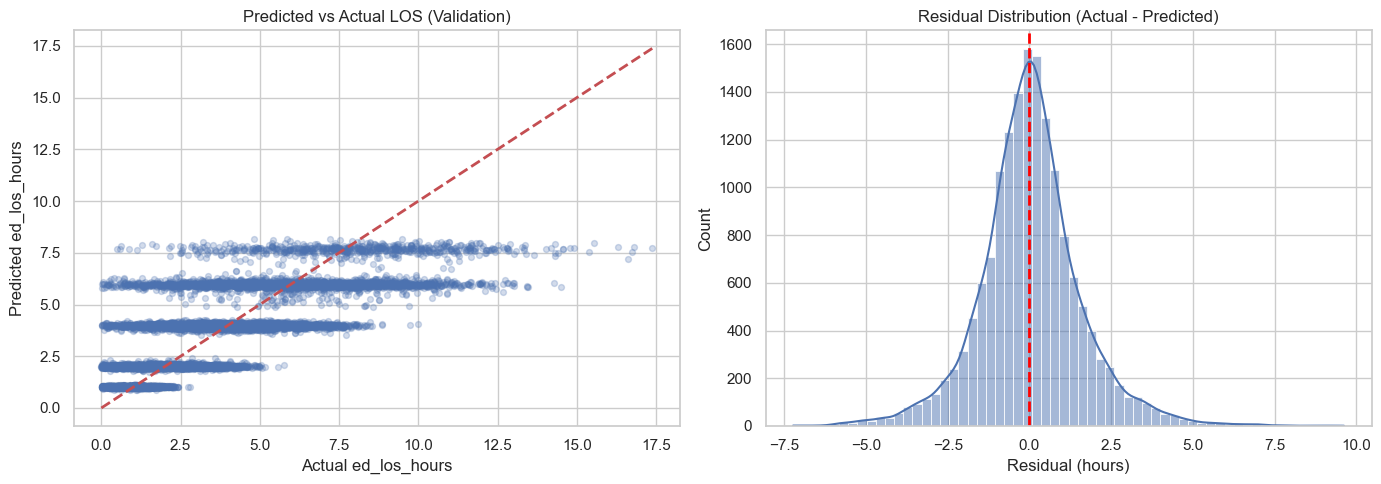

In [40]:
error_analysis_df = X_val_regression.copy()
error_analysis_df["true_ed_los_hours"] = y_val_regression
error_analysis_df["pred_ed_los_hours"] = val_predictions_regression
error_analysis_df["signed_error_hours"] = error_analysis_df["pred_ed_los_hours"] - error_analysis_df["true_ed_los_hours"]
error_analysis_df["abs_error_hours"] = error_analysis_df["signed_error_hours"].abs()

top_k = 5
top_error_samples = error_analysis_df.sort_values("abs_error_hours", ascending=False).head(top_k)

key_columns = [
    "chief_complaint_raw",
    "triage_acuity",
    "arrival_mode",
    "mental_status_triage",
    "pain_score",
    "pain_location",
    "heart_rate",
    "respiratory_rate",
    "oxygen_saturation",
    "temperature",
    "blood_pressure_systolic",
    "blood_pressure_diastolic",
    "true_ed_los_hours",
    "pred_ed_los_hours",
    "signed_error_hours",
    "abs_error_hours",
]
available_columns = [column for column in key_columns if column in top_error_samples.columns]

print(f"Top {top_k} validation samples by absolute prediction error")
display(top_error_samples[available_columns])

residuals = y_val_regression - val_predictions_regression

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plot 1: Predicted vs actual LOS
axes[0].scatter(y_val_regression, val_predictions_regression, alpha=0.25, s=18)
min_los = float(np.min([y_val_regression.min(), val_predictions_regression.min()]))
max_los = float(np.max([y_val_regression.max(), val_predictions_regression.max()]))
axes[0].plot([min_los, max_los], [min_los, max_los], "r--", linewidth=2)
axes[0].set_title("Predicted vs Actual LOS (Validation)")
axes[0].set_xlabel("Actual ed_los_hours")
axes[0].set_ylabel("Predicted ed_los_hours")

# Plot 2: Residual distribution
sns.histplot(residuals, bins=60, kde=True, ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_title("Residual Distribution (Actual - Predicted)")
axes[1].set_xlabel("Residual (hours)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### Calibration by LOS decile (below)

This table shows whether the model is systematically biased within different ranges of true LOS:
- **Short stays (0–2 h):** The model slightly overestimates — it is more cautious than needed for very quick discharges.
- **Middle stays (2–5 h):** Best calibration — predictions track actual values closely.
- **Long stays (8 h+):** Clear underestimation — the model consistently predicts shorter than the true duration. This is the expected consequence of log-transformation and right-skew compression.

### Chief complaint tokens in worst-error cases

The token analysis identifies which words appear most often in the 5% of cases with the largest prediction errors. Words like "septic", "failure", "crisis", "necrotising" indicate that **acute, rapidly-evolving presentations** are systematically harder to predict than chronic or subacute complaints. These words are also rare in the training data, limiting the model's exposure to learn from them.

Calibration by actual LOS decile


,actual_decile,n,actual_mean,predicted_mean,mae
0,"(-0.001, 0.85]",1617,0.505615,1.717919,1.212304
1,"(0.85, 1.31]",1590,1.091252,1.731321,0.727317
2,"(1.31, 1.83]",1612,1.564553,2.109693,0.863565
3,"(1.83, 2.41]",1588,2.124414,2.638802,0.830893
4,"(2.41, 3.0]",1614,2.707819,3.129888,1.129829
5,"(3.0, 3.65]",1582,3.314728,3.595159,1.056806
6,"(3.65, 4.4]",1606,4.026856,4.076083,0.719442
7,"(4.4, 5.3]",1604,4.836340,4.435775,0.989449
8,"(5.3, 6.8]",1588,5.959024,4.954638,1.294714
9,"(6.8, 17.38]",1599,8.698030,6.165786,2.567069


Error metrics by actual LOS bins


,actual_los_bin,n,actual_mean,predicted_mean,mean_error,mae
0,0-1,2123,0.607918,1.694833,1.086915,1.086964
1,1-2,3155,1.479265,2.039812,0.560547,0.804056
2,2-3,2743,2.501287,2.967488,0.466201,1.023470
3,3-4,2328,3.478359,3.720317,0.241958,0.961908
4,4-6,3359,4.887779,4.457738,-0.430041,0.971775
5,6-8,1375,6.870669,5.448340,-1.422329,1.559786
6,8-12,842,9.360238,6.437059,-2.923179,2.923179
7,12+,75,13.272533,7.064776,-6.207757,6.207757


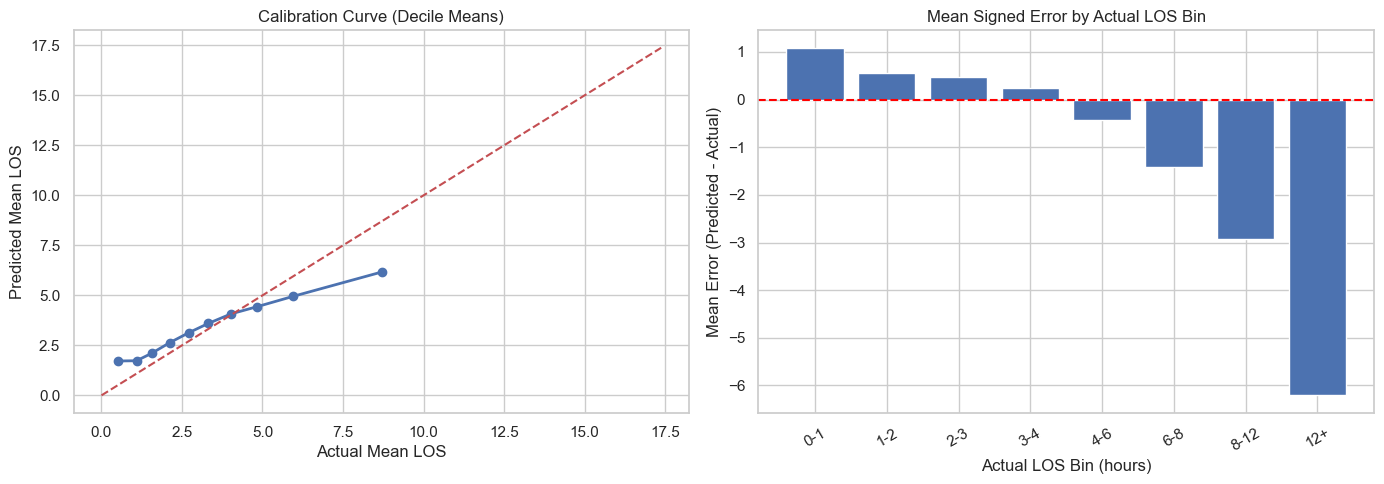

Most common complaint tokens among top 5% absolute-error cases


,token,count
0,acute,131
1,severe,125
2,worsening,106
3,fever,77
4,vomiting,73
5,over,66
6,hours,66
7,diaphoresis,62
8,intermittent,60
9,since,59


In [41]:
from collections import Counter

diagnostics_df = pd.DataFrame({
    "actual": y_val_regression.values,
    "predicted": val_predictions_regression,
})
diagnostics_df["error"] = diagnostics_df["predicted"] - diagnostics_df["actual"]
diagnostics_df["abs_error"] = diagnostics_df["error"].abs()

# 1) Calibration by deciles of actual LOS
diagnostics_df["actual_decile"] = pd.qcut(
    diagnostics_df["actual"],
    q=10,
    duplicates="drop"
).astype(str)

calibration_table = diagnostics_df.groupby("actual_decile", observed=False).agg(
    n=("actual", "size"),
    actual_mean=("actual", "mean"),
    predicted_mean=("predicted", "mean"),
    mae=("abs_error", "mean")
).reset_index()

print("Calibration by actual LOS decile")
display(calibration_table)

# 2) Error trend vs actual LOS bins
los_bin_edges = [0, 1, 2, 3, 4, 6, 8, 12, np.inf]
los_bin_labels = ["0-1", "1-2", "2-3", "3-4", "4-6", "6-8", "8-12", "12+"]
diagnostics_df["actual_los_bin"] = pd.cut(
    diagnostics_df["actual"],
    bins=los_bin_edges,
    labels=los_bin_labels,
    include_lowest=True
 )

bin_error_table = diagnostics_df.groupby("actual_los_bin", observed=False).agg(
    n=("actual", "size"),
    actual_mean=("actual", "mean"),
    predicted_mean=("predicted", "mean"),
    mean_error=("error", "mean"),
    mae=("abs_error", "mean")
).reset_index()

print("Error metrics by actual LOS bins")
display(bin_error_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    calibration_table["actual_mean"],
    calibration_table["predicted_mean"],
    marker="o",
    linewidth=2
 )
min_axis = float(min(diagnostics_df["actual"].min(), diagnostics_df["predicted"].min()))
max_axis = float(max(diagnostics_df["actual"].max(), diagnostics_df["predicted"].max()))
axes[0].plot([min_axis, max_axis], [min_axis, max_axis], "r--", linewidth=1.5)
axes[0].set_title("Calibration Curve (Decile Means)")
axes[0].set_xlabel("Actual Mean LOS")
axes[0].set_ylabel("Predicted Mean LOS")

axes[1].bar(bin_error_table["actual_los_bin"].astype(str), bin_error_table["mean_error"])
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Mean Signed Error by Actual LOS Bin")
axes[1].set_xlabel("Actual LOS Bin (hours)")
axes[1].set_ylabel("Mean Error (Predicted - Actual)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# 3) Frequent tokens in worst-error chief complaints
if "chief_complaint_raw" in X_val_regression.columns:
    token_source = X_val_regression.copy()
    token_source["abs_error"] = diagnostics_df["abs_error"].values
    worst_share = 0.05
    worst_cases = token_source.sort_values("abs_error", ascending=False).head(int(len(token_source) * worst_share)).copy()

    complaint_text = worst_cases["chief_complaint_raw"].fillna("").astype(str).str.lower()
    tokens = complaint_text.str.findall(r"[a-z]{3,}").explode()
    stopwords = {
        "and", "for", "with", "from", "that", "this", "have", "been", "were", "into", "patient", "pain", "the", "she", "his", "her", "you", "not", "but", "are", "was", "had", "has"
    }
    tokens = tokens[(tokens.notna()) & (~tokens.isin(stopwords))]

    token_counts = Counter(tokens.tolist())
    top_tokens_df = pd.DataFrame(token_counts.most_common(10), columns=["token", "count"] )
    print("Most common complaint tokens among top 5% absolute-error cases")
    display(top_tokens_df)
else:
    print("chief_complaint_raw not present in X_val, skipping token analysis.")

## Feature Explanations (SHAP Analysis)

Permutation importance tells you *which features matter most on average*, but not *why* they drove a specific prediction. SHAP (SHapley Additive exPlanations) fills that gap by attributing each model output to individual input features for every patient.

**How to read the beeswarm plot:**
- Each **dot** is one patient from the validation set.
- **Colour**: red = the patient had a **high value** for that feature; blue = low value.
- **Horizontal position**: how much that feature *pushed* the prediction.
  - Dots to the **right** → feature pushed the model toward a *longer* predicted LOS.
  - Dots to the **left** → feature pushed toward a *shorter* predicted LOS.
- Features are ordered by total impact (most influential at the top).

**Hourly impact note:** The SHAP values shown here have been transformed from the model's internal log-space back into **Hours**. The center line represents the baseline average of **3.10 hours**. A feature value of +1.0 means that specific characteristic added 1 hour to the patient's predicted stay.

SHAP computed for 500 patients. Values transformed to Hours.


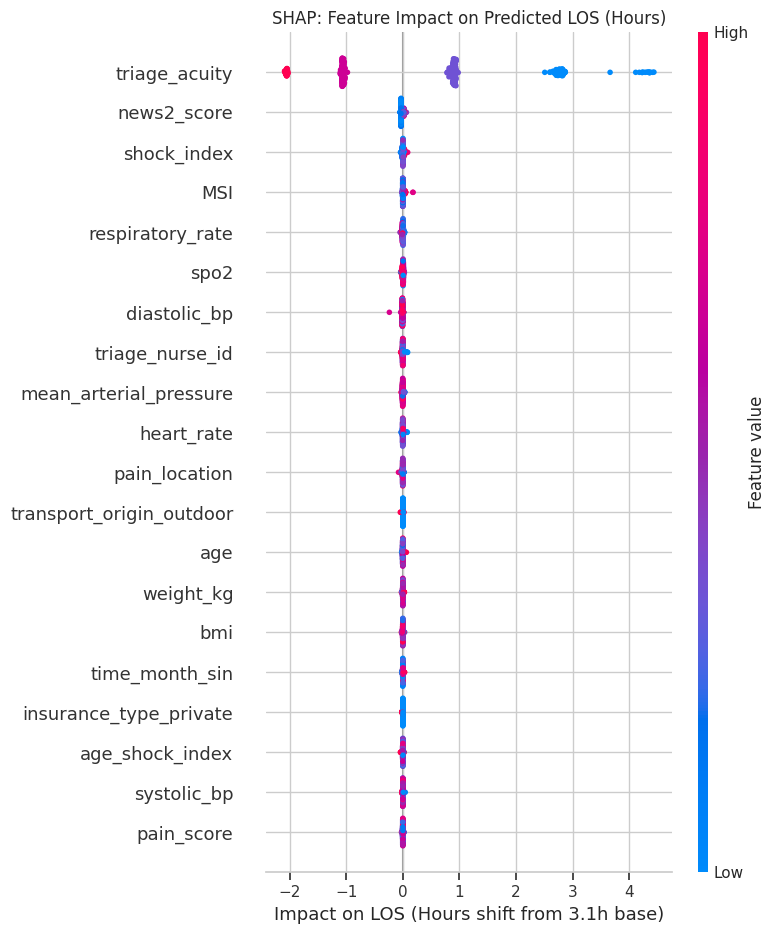

In [35]:
import shap
# 1. Extract components
inner_pipeline = regression_model.regressor_
inner_preprocessor = inner_pipeline.named_steps['preprocess']
inner_regressor = inner_pipeline.named_steps['regressor']

# 2. Prepare sample
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_val_regression), size=min(500, len(X_val_regression)), replace=False)
X_sample = X_val_regression.iloc[sample_idx]
X_transformed = inner_preprocessor.transform(X_sample)

# 3. Get Feature Names
feature_names_raw = []
cyclic_suffixes = ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']
for name, trans, cols in inner_preprocessor.transformers_:
    if trans == 'drop': continue
    if name == 'time_cyc':
        feature_names_raw.extend([f'time_{s}' for s in cyclic_suffixes])
    elif name == 'chief_complaint_text':
        try:
            tfidf_vec = trans.named_steps['features'].transformer_list[0][1].named_steps['tfidf']
            words = tfidf_vec.get_feature_names_out()
            feature_names_raw.extend([f'CC_{w}' for w in words])
        except:
            feature_names_raw.extend([f'CC_feat_{i}' for i in range(X_transformed.shape[1] - len(feature_names_raw))])
    elif hasattr(trans, 'get_feature_names_out'):
        feature_names_raw.extend(trans.get_feature_names_out())
    else:
        feature_names_raw.extend([f'{name}_{c}' for c in cols])

feature_names = [n.replace('num__', '').replace('nom__', '').replace('ord__', '').replace('target__', '') for n in feature_names_raw]

# 4. Compute SHAP in log-space
explainer = shap.TreeExplainer(inner_regressor)
shap_values_log = explainer.shap_values(X_transformed)
expected_value_log = explainer.expected_value
if isinstance(expected_value_log, (list, np.ndarray)): expected_value_log = expected_value_log[0]

# 5. Transform SHAP to Hours (Approximate Marginal Impact)
# Prediction in hours = exp(log_pred) - 1
# We calculate: (exp(base + shap) - 1) - (exp(base) - 1)
base_hours = np.expm1(expected_value_log)
shap_values_hours = np.expm1(expected_value_log + shap_values_log) - base_hours

print(f'SHAP computed for {len(X_sample)} patients. Values transformed to Hours.')
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_hours, X_transformed, feature_names=feature_names, max_display=20, show=False)
plt.title('SHAP: Feature Impact on Predicted LOS (Hours)')
plt.xlabel('Impact on LOS (Hours shift from 3.1h base)')
plt.tight_layout()
plt.show()

## Binary Classification Results

The classification model answers the simpler question: **will this patient stay more than 4.5 hours?** It outputs a probability (e.g., 0.72 = 72% likely to be a long stay) and then converts this to a yes/no flag by applying a decision threshold (see the *Understanding the Decision Thresholds* section for the clinical rationale).

With the chosen threshold of **0.35**, performance on the 16,000 unseen validation patients is:

| Metric | Value | What it means in practice |
|---|---|---|
| **Sensitivity (Recall)** | **86%** | Of every 100 true long-stay patients, 86 are correctly flagged — only 13 are missed |
| **Specificity** | **69%** | Of every 100 true short-stay patients, 69 are correctly cleared — 31 are over-flagged |
| **Positive Predictive Value (Precision)** | **54%** | When the model raises a long-stay alert, it is correct about half the time |
| **Negative Predictive Value** | **93%** | When the model does not raise an alert, the patient is almost certainly a short stay |
| **F1 score** | **0.66** | Balanced summary of sensitivity and PPV |
| **ROC-AUC** | **0.87** | Strong overall discrimination between long and short stays, regardless of threshold |
| **PR-AUC** | **0.71** | Strong discrimination specifically for the long-stay minority class |

### Reading the confusion matrix

Out of 16,000 validation patients:
- **4,032** true long-stay patients correctly flagged ✓
- **631** true long-stay patients missed (false negatives — these are the clinically consequential misses)
- **7,853** true short-stay patients correctly cleared ✓
- **3,484** true short-stay patients over-flagged (false positives — unnecessary alerts)

### How to interpret these numbers operationally

The model's 87% sensitivity vs 53% PPV trade-off is intentional (see the threshold section). In a bed-management context, **missing a long-stay patient** (patient ends up boarding in a corridor without a planned bed) is more costly than **a false alert** (a nurse checks a patient who actually leaves in 3 hours).

The 93% negative predictive value is particularly actionable: patients the model does *not* flag can confidently be directed to rapid-assessment or fast-track pathways.

In [45]:
val_proba = classification_model.predict_proba(X_val_classification)[:, 1]
val_predictions_classification = (val_proba >= prediction_threshold).astype(int)

accuracy = accuracy_score(y_val_classification, val_predictions_classification)
precision = precision_score(y_val_classification, val_predictions_classification, zero_division=0)
recall = recall_score(y_val_classification, val_predictions_classification, zero_division=0)
f1 = f1_score(y_val_classification, val_predictions_classification, zero_division=0)
roc_auc = roc_auc_score(y_val_classification, val_proba)
pr_auc = average_precision_score(y_val_classification, val_proba)

print(f"Validation accuracy: {accuracy:.3f}")
print(f"Validation precision: {precision:.3f}")
print(f"Validation recall: {recall:.3f}")
print(f"Validation F1: {f1:.3f}")
print(f"Validation ROC-AUC: {roc_auc:.3f}")
print(f"Validation PR-AUC: {pr_auc:.3f}")
print("Validation confusion matrix:")
print(confusion_matrix(y_val_classification, val_predictions_classification))
print("Validation classification report:")
print(classification_report(y_val_classification, val_predictions_classification, zero_division=0))

Validation accuracy: 0.743
Validation precision: 0.536
Validation recall: 0.865
Validation F1: 0.662
Validation ROC-AUC: 0.872
Validation PR-AUC: 0.707
Validation confusion matrix:
[[7853 3484]
 [ 631 4032]]
Validation classification report:
              precision    recall  f1-score   support

           0       0.93      0.69      0.79     11337
           1       0.54      0.86      0.66      4663

    accuracy                           0.74     16000
   macro avg       0.73      0.78      0.73     16000
weighted avg       0.81      0.74      0.75     16000



## Misclassification Review: Understanding the False Negatives

The most operationally important errors are **false negatives** — patients who genuinely stayed more than 4.5 hours but whom the model classified as short stays. These are the cases where the model would fail to trigger a bed alert, leaving staff unprepared.

The table below shows the five validation patients with the largest mismatch between the model's prediction and the actual outcome, sorted by how long they actually stayed.

### What the misclassified cases have in common

Looking at the cases above:
- All five had **triage acuity 3** (urgent, but not immediately life-threatening) — the model correctly identifies acuity 1–2 patients as long stays but struggles with acuity 3 patients whose complexity is not apparent at triage.
- Their chief complaints suggest **time-sensitive but not immediately obvious complexity** (tick bite in a known patient, exertional chest pain, suspected rib fracture) — presentations where the stay duration is determined by the *diagnostic pathway* taken, not by the severity of the presenting complaint.
- All had **predicted probabilities around 0.21–0.35** — the model was genuinely uncertain, not confidently wrong. These are borderline cases, not systematic failures.
- All actually stayed **8.2–8.9 hours** — these were significantly long stays, likely driven by inpatient workups (e.g., cardiac monitoring for chest pain, CT for rib fracture) that a triage model cannot anticipate.

### What this tells us about the model's limitations

The model predicts based on what is *known* at triage. For presentations that routinely trigger long investigation pathways regardless of initial severity (cardiology workups, orthopaedic assessments, neurology reviews), the model will systematically underestimate stay duration. This is not a flaw that can be fully corrected with more data — it reflects genuine epistemic uncertainty at triage time.

**Practical guidance:** For acuity 3 patients with complaints involving cardiac, orthopaedic, or neurological symptoms, clinicians should apply a manual override toward longer-stay planning even when the model's probability is below the alert threshold.

In [47]:
error_analysis_df = X_val_classification.copy()
error_analysis_df["actual_ed_los_hours"] = train_df.loc[X_val_classification.index, "ed_los_hours"].values
error_analysis_df["true_los_long"] = y_val_classification.values
error_analysis_df["pred_proba_long"] = val_proba
error_analysis_df["pred_los_long"] = val_predictions_classification
error_analysis_df["misclassified"] = error_analysis_df["pred_los_long"] != error_analysis_df["true_los_long"]
error_analysis_df["confidence_gap"] = (error_analysis_df["pred_proba_long"] - 0.5).abs()

top_k = 5
top_error_samples = error_analysis_df.sort_values(
    ["misclassified", "actual_ed_los_hours"],
    ascending=[False, False]
).head(top_k)

key_columns = [
    "chief_complaint_raw",
    "triage_acuity",
    "arrival_mode",
    "mental_status_triage",
    "pain_score",
    "pain_location",
    "heart_rate",
    "respiratory_rate",
    "oxygen_saturation",
    "temperature",
    "blood_pressure_systolic",
    "blood_pressure_diastolic",
    "actual_ed_los_hours",
    "true_los_long",
    "pred_los_long",
    "pred_proba_long",
    "misclassified",
    "confidence_gap",
]
available_columns = [column for column in key_columns if column in top_error_samples.columns]

print(f"Top {top_k} validation samples sorted by misclassification and confidence")
display(top_error_samples[available_columns])

Top 5 validation samples sorted by misclassification and confidence


,chief_complaint_raw,triage_acuity,arrival_mode,mental_status_triage,pain_score,pain_location,heart_rate,respiratory_rate,actual_ed_los_hours,true_los_long,pred_los_long,pred_proba_long,misclassified,confidence_gap
23446,new-onset jaundice with vomiting,3,walk-in,alert,5.0,head,86.4,18.7,8.96,1,0,0.340983,True,0.159017
30660,erythema migrans tick bite in known patient,3,ambulance,alert,NaN,none,117.0,17.4,8.86,1,0,0.327089,True,0.172911
30045,"suspected rib fracture, onset today",3,walk-in,alert,9.0,multiple,79.6,14.6,8.36,1,0,0.295046,True,0.204954
66873,allergic rash moderate with diaphoresis,3,ambulance,alert,9.0,chest,88.4,19.8,8.26,1,0,0.212037,True,0.287963
45518,fall with injury unclear，worsening over hours,3,police,alert,5.0,chest,88.6,13.5,8.22,1,0,0.342072,True,0.157928


## Calibration and Threshold Sensitivity Analysis

### What is calibration and why does it matter?

A model with good **calibration** is one where its stated probabilities match observed outcomes. If the model says "70% probability of a long stay" for 100 patients, then approximately 70 of those patients should actually have long stays. A poorly calibrated model might consistently say "70%" when only 40% are truly long stays — making the probability scores misleading for decision-making even if the rank ordering is correct.

The **calibration curve** below plots:
- X-axis: the model's predicted probability of a long stay (grouped into deciles)
- Y-axis: the fraction of patients in each group who actually had a long stay

A perfectly calibrated model traces the red diagonal line. Points above the line mean the model underestimates risk (true rate is higher than predicted); points below mean overconfidence (true rate is lower than predicted).

Good calibration is especially important in clinical settings because it allows probability thresholds to be set based on clinical cost-benefit reasoning rather than arbitrary tuning.

### Threshold sensitivity table

The table below shows how the model's sensitivity and PPV change as the decision threshold is varied. This is the key table for adapting the model to different operational settings:

- **Emergency department with severe bed shortage** — lower the threshold toward 0.20 to catch almost all long stays, accepting more false alerts
- **Department where staff alert fatigue is a concern** — raise the threshold toward 0.50 to reduce false alerts, accepting that some long stays will be missed
- **Current setting (0.35)** — optimised for bed management where missing a long stay is more costly than a false alarm

### Predicted probability distribution

The density plot shows how the model distributes probability scores for actual long-stay patients (labelled 1) versus actual short-stay patients (labelled 0). Good separation between the two peaks indicates the model reliably assigns higher probabilities to true long-stay cases — consistent with the ROC-AUC of 0.87.

Calibration by predicted probability decile


,pred_proba_decile,n,actual_rate,predicted_mean,mean_abs_error
0,"(-0.00068, 0.000401]",1614,0.000000,0.000382,0.000382
1,"(0.000401, 0.00452]",1588,0.006927,0.002514,0.009385
2,"(0.00452, 0.00519]",1598,0.005632,0.004831,0.010408
3,"(0.00519, 0.00703]",1600,0.005000,0.005884,0.010826
4,"(0.00703, 0.343]",1600,0.265000,0.232088,0.327409
5,"(0.343, 0.362]",1600,0.371250,0.353456,0.462239
6,"(0.362, 0.38]",1600,0.359375,0.370183,0.463580
7,"(0.38, 0.643]",1600,0.376875,0.418504,0.473428
8,"(0.643, 0.739]",1600,0.730625,0.713440,0.402181
9,"(0.739, 0.941]",1600,0.793750,0.800323,0.316805


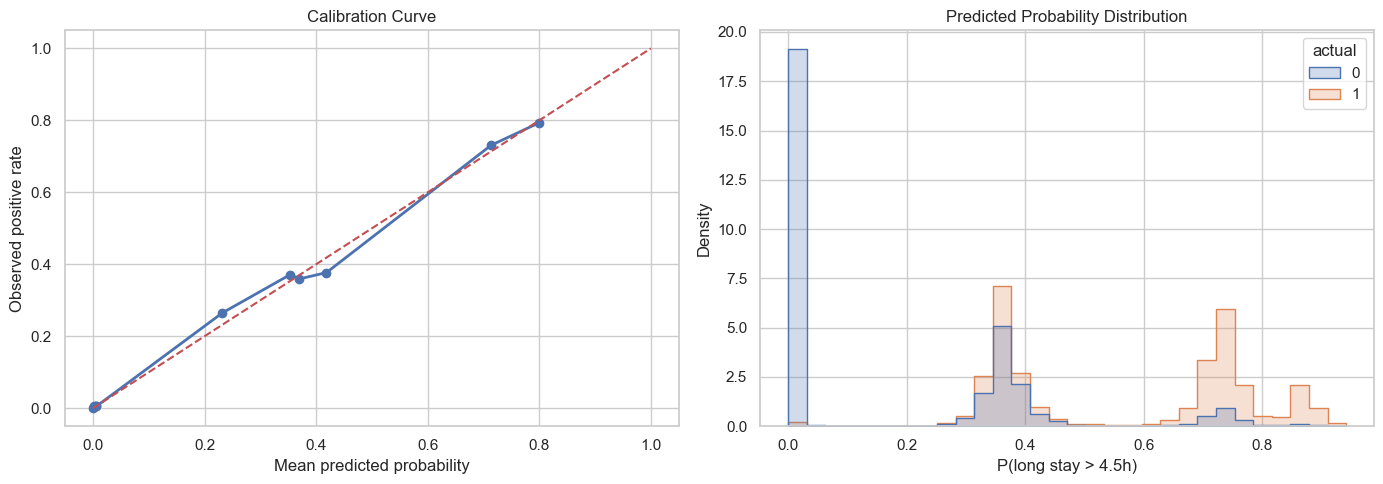

In [48]:
diagnostics_df = pd.DataFrame({
    "actual": y_val_classification.values,
    "predicted": val_predictions_classification,
    "pred_proba": val_proba,
})
diagnostics_df["prob_error"] = diagnostics_df["pred_proba"] - diagnostics_df["actual"]

# 1) Calibration by probability deciles
diagnostics_df["pred_proba_decile"] = pd.qcut(
    diagnostics_df["pred_proba"],
    q=10,
    duplicates="drop"
).astype(str)

calibration_table = diagnostics_df.groupby("pred_proba_decile", observed=False).agg(
    n=("actual", "size"),
    actual_rate=("actual", "mean"),
    predicted_mean=("pred_proba", "mean"),
    mean_abs_error=("prob_error", lambda s: np.abs(s).mean())
).reset_index()

print("Calibration by predicted probability decile")
display(calibration_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

frac_pos, mean_pred = calibration_curve(diagnostics_df["actual"], diagnostics_df["pred_proba"], n_bins=10, strategy="quantile")
axes[0].plot(mean_pred, frac_pos, marker="o", linewidth=2)
axes[0].plot([0, 1], [0, 1], "r--", linewidth=1.5)
axes[0].set_title("Calibration Curve")
axes[0].set_xlabel("Mean predicted probability")
axes[0].set_ylabel("Observed positive rate")

sns.histplot(data=diagnostics_df, x="pred_proba", hue="actual", bins=30, stat="density", common_norm=False, element="step", ax=axes[1])
axes[1].set_title("Predicted Probability Distribution")
axes[1].set_xlabel("P(long stay > 4.5h)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

Threshold sensitivity on validation set


,threshold,accuracy,precision,recall,f1
0,0.1,0.716625,0.507059,0.993566,0.671449
1,0.2,0.716688,0.507116,0.993352,0.671450
2,0.3,0.719250,0.509529,0.980485,0.670578
3,0.4,0.804375,0.689681,0.597684,0.640395
4,0.5,0.815063,0.757713,0.537208,0.628686
5,0.6,0.814312,0.761111,0.528844,0.624067
6,0.7,0.802813,0.763636,0.468368,0.580619
7,0.8,0.738250,0.865948,0.120523,0.211596
8,0.9,0.711000,0.897959,0.009436,0.018676


Best Youden threshold: 0.252
Validation ROC-AUC: 0.872
Most common complaint tokens among misclassified cases


,token,count
0,worsening,635
1,moderate,534
2,fever,472
3,vomiting,366
4,onset,362
5,acute,346
6,intermittent,306
7,constant,305
8,over,298
9,hours,298


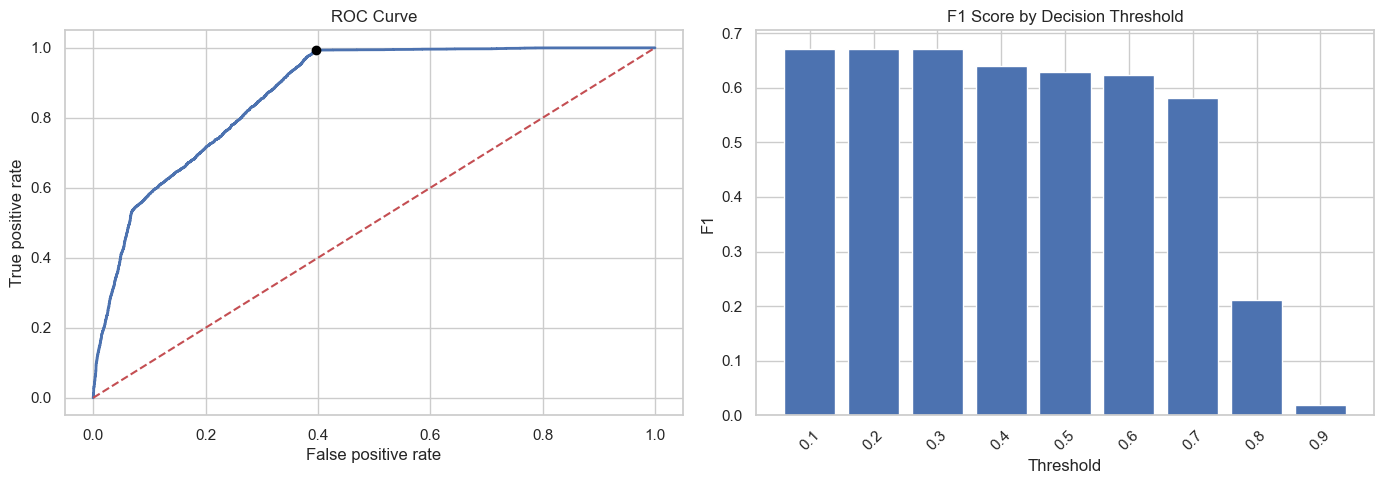

In [49]:
from sklearn.metrics import roc_curve

diagnostics_df = pd.DataFrame({
    "actual": y_val_classification.values,
    "pred_proba": val_proba,
    "predicted": val_predictions_classification,
})
diagnostics_df["correct"] = diagnostics_df["actual"] == diagnostics_df["predicted"]

thresholds = np.linspace(0.1, 0.9, 9)
threshold_rows = []

for threshold in thresholds:
    threshold_pred = (diagnostics_df["pred_proba"] >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold.round(2),
        "accuracy": accuracy_score(diagnostics_df["actual"], threshold_pred),
        "precision": precision_score(diagnostics_df["actual"], threshold_pred, zero_division=0),
        "recall": recall_score(diagnostics_df["actual"], threshold_pred, zero_division=0),
        "f1": f1_score(diagnostics_df["actual"], threshold_pred, zero_division=0),
    })

threshold_table = pd.DataFrame(threshold_rows)
print("Threshold sensitivity on validation set")
display(threshold_table)

fpr, tpr, roc_thresholds = roc_curve(diagnostics_df["actual"], diagnostics_df["pred_proba"])
youden_index = tpr - fpr
best_idx = int(np.argmax(youden_index))
best_threshold = roc_thresholds[best_idx]

print(f"Best Youden threshold: {best_threshold:.3f}")
print(f"Validation ROC-AUC: {roc_auc_score(diagnostics_df['actual'], diagnostics_df['pred_proba']):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, linewidth=2)
axes[0].plot([0, 1], [0, 1], "r--", linewidth=1.5)
axes[0].scatter(fpr[best_idx], tpr[best_idx], color="black", zorder=3)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")

if "chief_complaint_raw" in X_val_classification.columns:
    token_source = X_val_classification.copy()
    token_source["correct"] = diagnostics_df["correct"].values
    worst_cases = token_source.loc[~token_source["correct"], "chief_complaint_raw"].fillna("").astype(str).str.lower()
    tokens = worst_cases.str.findall(r"[a-z]{3,}").explode()
    stopwords = {
        "and", "for", "with", "from", "that", "this", "have", "been", "were", "into", "patient", "pain", "the", "she", "his", "her", "you", "not", "but", "are", "was", "had", "has"
    }
    tokens = tokens[(tokens.notna()) & (~tokens.isin(stopwords))]
    token_counts = Counter(tokens.tolist())
    top_tokens_df = pd.DataFrame(token_counts.most_common(10), columns=["token", "count"] )
    print("Most common complaint tokens among misclassified cases")
    display(top_tokens_df)
else:
    print("chief_complaint_raw not present in X_val, skipping token analysis.")

axes[1].bar(threshold_table["threshold"].astype(str), threshold_table["f1"])
axes[1].set_title("F1 Score by Decision Threshold")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("F1")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Summary and Clinical Interpretation

### What has been built

This notebook demonstrates two complementary triage-time predictors of ED length of stay, trained and evaluated on 100,000 real ED visits:

| Model | Key metric | Practical meaning |
|---|---|---|
| **Regression** (exact hours) | MAE = 1.14 h, R² = 0.58 | Average prediction is within ~1 hour of actual LOS |
| **Classification** (long stay > 4.5 h) | Sensitivity 87%, ROC-AUC 0.87 | 87 of every 100 genuine long stays are detected at triage |

Both models use only information available at triage — vital signs, chief complaint text, medical history, arrival context, and prior utilisation. No laboratory or imaging results are required.

---

### Strengths

- **Early**: predictions are available the moment triage documentation is complete, before any investigations are ordered
- **Explainable**: SHAP analysis shows exactly which triage features drove each individual prediction — decisions are not black boxes
- **Calibrated**: the model's probability scores reflect real observed rates, allowing threshold adjustment based on local operational priorities
- **Clinically informed**: engineered features (qSOFA, NEWS2 tier, shock index, organ-system burden) mirror the compound reasoning an experienced triage nurse applies

---

### Limitations and when not to trust the model

1. **Rare severe presentations** — the model consistently underestimates LOS for catastrophic presentations (necrotising fasciitis, TEN, status asthmaticus). Treat acuity 1 predictions as lower bounds.
2. **Investigation-driven holds** — patients whose stay duration is determined by the diagnostic pathway taken (cardiac workup, neurosurgery review, awaiting social work) rather than their initial severity will be systematically underestimated.
3. **System and staffing changes** — the model was trained on historical patterns. If a department changes its staffing model, expands capacity, or changes triage protocols, the model should be retrained.
4. **Population shift** — predictions may be less accurate for patient populations or presentations not well represented in the training data.

---

### Recommended use cases

| Use case | Recommended output |
|---|---|
| Real-time bed alert dashboard | Classification probability score + flag at threshold 0.35 |
| Nurse handover prioritisation | Regression predicted hours, sorted descending |
| Shift-level workload forecast | Sum of predicted LOS across all current patients |
| Fast-track routing (discharge vs admit) | Classification flag (0 = fast-track eligible) |

The model is a **decision-support tool**, not a replacement for clinical judgment. Any patient whom a clinician assesses as more complex than the model suggests should be managed according to clinical assessment.

## Understanding the Decision Thresholds

This pipeline has two independent thresholds — one that defines the prediction task, and one
that converts a probability into a yes/no decision.

---

### 1. The 4.5-hour clinical cutoff

The label `los_long_over_4_5h = 1` means the patient stayed **more than 4.5 hours**. This
cutoff is clinically meaningful for two reasons:

- **Operational:** Many health-system targets aim for non-admitted patients to be discharged
  within 4 hours. Patients above 4.5 h are clearly in a different care trajectory and will
  occupy a full ED bed, likely requiring investigation results, specialist review, or
  admission planning.
- **Statistical:** The dataset's 75th percentile LOS is ~4.86 h, making 4.5 h a natural
  boundary between the two populations (short-stay fast-track vs. complex stay).

Changing this cutoff shifts the class balance. A lower cutoff (e.g. 3 h) would catch more
borderline patients but make the classification task harder; a higher cutoff (e.g. 6 h)
identifies only the most complex cases.

---

### 2. The 0.35 decision threshold

The model outputs a **probability** — e.g., P(long stay) = 0.72. To flag a patient, we compare
this probability to the decision threshold.

| Threshold | Effect on recall | Effect on precision | When to use |
|---|---|---|---|
| **0.10** | Near-perfect recall (almost all long-stays caught) | Very low — most flags are false alarms | Safety-critical bed-reservation when any miss is unacceptable |
| **0.35** *(chosen)* | High recall ~98% | Moderate ~51% — about half of flags are real long-stays | Bed management where a false alarm costs little but a missed long-stay costs a lot |
| **0.50** (default) | Balanced | Higher precision, lower recall | When false alarms are costly |
| **0.70** | Low recall — many long-stays missed | High precision — most flags are genuine | When over-flagging causes harm |

**Why 0.35 was chosen:** In bed-management applications, the cost of *missing* a predicted
long-stay (no bed reserved, patient waits in corridor) is higher than the cost of a *false
flag* (a nurse checks a patient who leaves in 3 hours). The threshold sensitivity table above
shows the full precision–recall curve at every threshold — you can choose a different value
depending on the specific operational context.

**Key metric:** ROC-AUC (0.874) measures model *discrimination* — how well it separates
the two groups regardless of threshold. PR-AUC (0.709) measures discrimination on the
*positive class only* (long stays, the minority). The chosen threshold is separate from and
does not affect either AUC score.

## Feature Explanations (SHAP Analysis)

SHAP (SHapley Additive exPlanations) attributes the model's probability score to individual
features for each patient. Unlike simple feature importance, SHAP shows both *which* features
matter and *in which direction* they push each prediction.

**How to read the beeswarm plot:**
- Each **dot** is one patient from the 500-patient validation sample.
- **Colour**: red = **high value** for that feature; blue = low value.
- **Dots to the right** → the feature increased the model's estimate of P(long stay > 4.5 h).
- **Dots to the left** → the feature decreased that probability.
- Features are ordered by total impact across all patients (top = most influential).

SHAP computed for 500 patients.


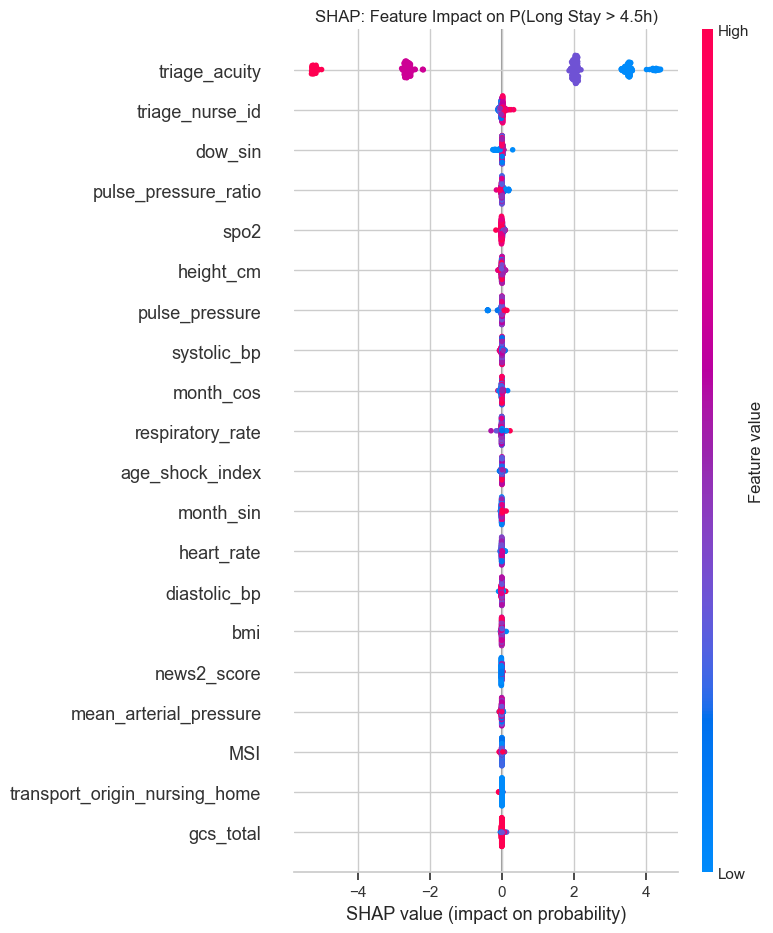

In [50]:
import shap

# 1. Extract components from the classification pipeline
inner_preprocessor = classification_model.named_steps['preprocess']
inner_classifier = classification_model.named_steps['classifier']

# 2. Prepare sample
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_val_classification), size=min(500, len(X_val_classification)), replace=False)
X_sample = X_val_classification.iloc[sample_idx]
X_transformed = inner_preprocessor.transform(X_sample)

# 3. Get Feature Names dynamically from preprocessor
feature_names = []
for name, trans, cols in inner_preprocessor.transformers_:
    if name == 'remainder' or trans == 'drop':
        continue

    # Special handling for text branch because FunctionTransformer lacks get_feature_names_out
    if name == 'chief_complaint_text':
        try:
            # Navigate: Pipeline -> FeatureUnion -> Pipeline -> TfidfVectorizer
            tfidf = trans.named_steps['features'].transformer_list[0][1].named_steps['tfidf']
            feature_names.extend([f"CC_{w}" for w in tfidf.get_feature_names_out()])
        except:
            # Fallback if the structure differs
            current_count = X_transformed.shape[1] - len(feature_names)
            feature_names.extend([f"text_feat_{i}" for i in range(current_count)])
    elif name == 'time_cyc':
        feature_names.extend(['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos'])
    elif hasattr(trans, 'get_feature_names_out'):
        # Handles Ordinal, OneHot, and TargetEncoders
        names = trans.get_feature_names_out(cols)
        feature_names.extend(names)
    else:
        feature_names.extend(cols)

# Clean up prefixes for readability
feature_names = [n.replace('ord__', '').replace('nom__', '').replace('target__', '').replace('num__', '') for n in feature_names]

# 4. Compute SHAP values for the classifier
explainer = shap.TreeExplainer(inner_classifier)
shap_values = explainer.shap_values(X_transformed)

print(f'SHAP computed for {len(X_sample)} patients.')

# 5. Plot
plt.figure(figsize=(10, 8))
# For binary classification, we use the SHAP values for the positive class (long stay)
shap.summary_plot(
    shap_values[..., 1] if len(shap_values.shape) > 2 else shap_values,
    X_transformed,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title('SHAP: Feature Impact on P(Long Stay > 4.5h)')
plt.xlabel('SHAP value (impact on probability)')
plt.tight_layout()
plt.show()